# Anomaly Detection — Isolation Forest

- Isolation Forest: isolates anomalies by randomly splitting features — anomalies are isolated in fewer splits
- Tree-based, works in high dimensions, no distribution assumptions
- Dataset: creditcard.csv (flagging fraudulent transactions as anomalies)[http://kaggle.com/datasets/jacklizhi/creditcard](https://)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('/content/creditcard[1].csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142681,84874,-1.175585,-0.435225,1.228103,0.052441,1.503111,-2.004394,-0.122498,-0.046657,-0.325656,...,-0.066904,-0.643857,0.314354,0.337604,-0.403670,-0.122969,-0.016914,0.101735,1.98,0.0
142682,84874,1.241407,-0.414978,-0.880402,-1.049339,1.638588,3.350938,-0.809687,0.865613,0.244406,...,-0.223144,-0.895358,0.084569,1.038418,0.155673,0.799608,-0.067291,0.014978,44.62,0.0
142683,84875,-1.329905,0.864110,0.177223,-0.902612,1.291457,4.002512,-1.207749,1.972494,-0.153283,...,0.038467,-0.217288,-0.119543,1.036008,0.056579,0.301629,-0.283690,-0.036675,11.50,0.0
142684,84876,-0.636351,1.257445,1.521837,-0.027459,0.006568,-1.158053,1.058088,-0.476554,0.360277,...,-0.417344,-0.675847,-0.031819,0.635950,-0.178399,0.006644,0.133808,-0.227752,7.96,0.0


In [4]:
print("Shape:", df.shape)
print("Class distribution:\n", df["Class"].value_counts())

# Sample for speed — keeping class imbalance intact
df_sample = df.sample(n=10000, random_state=42)
X = df_sample.drop("Class", axis=1)
Y = df_sample["Class"]

Shape: (142686, 31)
Class distribution:
 Class
0.0    142414
1.0       271
Name: count, dtype: int64


In [5]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

model = IsolationForest(n_estimators=100, contamination=0.002, random_state=42)
model.fit(X_scaled)

predictions = model.predict(X_scaled)

# sklearn returns 1 for normal, -1 for anomaly — convert to 0/1 to match fraud labels
predictions_binary = np.where(predictions == -1, 1, 0)

print("Anomalies flagged:", predictions_binary.sum())
print("Actual fraud     :", Y.sum())

Anomalies flagged: 20
Actual fraud     : 24.0


In [6]:
scores = model.decision_function(X_scaled)

# Lower score = more anomalous
df_sample = df_sample.copy()
df_sample["anomaly_score"] = scores
df_sample["predicted_fraud"] = predictions_binary

print(df_sample[["Class", "anomaly_score", "predicted_fraud"]].sort_values("anomaly_score").head(10))

       Class  anomaly_score  predicted_fraud
42958    1.0      -0.061514                1
37000    0.0      -0.059162                1
15566    1.0      -0.045232                1
52524    0.0      -0.037950                1
9035     1.0      -0.037680                1
62413    0.0      -0.034391                1
12156    0.0      -0.032351                1
26686    0.0      -0.030176                1
12325    0.0      -0.029151                1
10456    0.0      -0.028840                1


In [7]:
cm = confusion_matrix(Y, predictions_binary)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(Y, predictions_binary))

Confusion Matrix:
 [[9963   13]
 [  17    7]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9976
         1.0       0.35      0.29      0.32        24

    accuracy                           1.00     10000
   macro avg       0.67      0.65      0.66     10000
weighted avg       1.00      1.00      1.00     10000



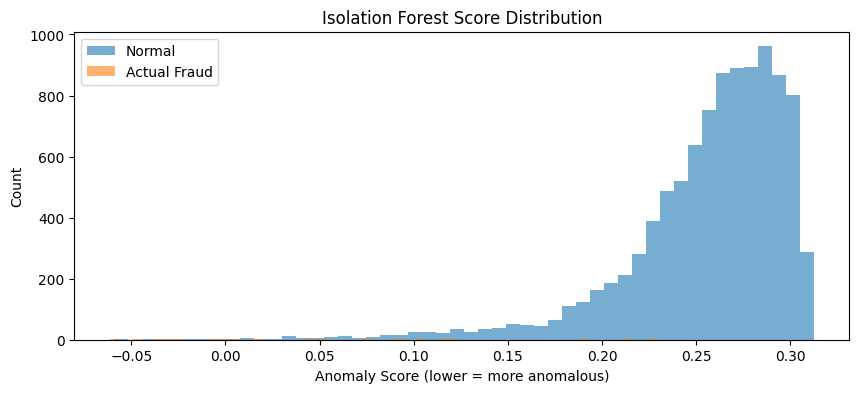

In [8]:
plt.figure(figsize=(10, 4))
plt.hist(scores[Y==0], bins=50, alpha=0.6, label="Normal")
plt.hist(scores[Y==1], bins=50, alpha=0.6, label="Actual Fraud")
plt.xlabel("Anomaly Score (lower = more anomalous)")
plt.ylabel("Count")
plt.title("Isolation Forest Score Distribution")
plt.legend()
plt.show()

## Conclusion
- Isolation Forest built 100 random trees and flagged transactions that were isolated in fewer splits as anomalies
- The contamination parameter (0.002) guided how many points were flagged — tuned to the dataset's known fraud rate
- Score distribution showed actual fraud transactions clustering at lower anomaly scores — confirming the model detected genuine patterns without ever seeing the fraud labels
- Compared to IQR (univariate, per-feature), Isolation Forest detects multivariate anomalies across all features simultaneously — better suited for high-dimensional fraud detection

Save as Isolation_Forest.ipynb
Upload to 03_Machine_Learning/07_Anomaly_Detection/